# **Loading Data**

In [1]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')

from bertopic import BERTopic
from top2vec import Top2Vec

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/hanywijaya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/hanywijaya/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/Users/hanywijaya/.pyenv/versions/3.10.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/hanywijaya/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
df_with_stopwords = pd.read_csv('../Data/Preprocessed_MBG.csv')
df_with_stopwords.head()

,Unnamed: 0,Tweet Count,Username,Text,Created At,Retweets,Likes
0,0,1,Fadli Dinul,me program mbg alias gajelas,Fri Jan 31 23:51:53 +0000 2025,0,8
1,1,2,JANGAN DITUNGGUIN DAN DITAGIH UPDATE AU🙏🏻,kapan orang yang tidak pernah commute pake tra...,Fri Jan 31 23:49:29 +0000 2025,1,7
2,2,3,nugrahagu,lihatlah indonesia bikin program mbg sebelumny...,Fri Jan 31 23:44:39 +0000 2025,0,0
3,3,4,Bulliever Shinobi,enteng banget nyuruh inovasi hasil pengorbanan...,Fri Jan 31 23:35:47 +0000 2025,0,5
4,4,5,Humas Polres Nganjuk,program makan bergizi gratis mbg polres nganju...,Fri Jan 31 23:33:55 +0000 2025,0,6


In [4]:
df_without_stopwords = pd.read_csv('../Data/PreprocessedWithoutStopwords_MBG.csv')
df_without_stopwords.head()

,Unnamed: 0,Tweet Count,Username,Text,Created At,Retweets,Likes
0,0,1,Fadli Dinul,me program mbg alias gajelas,Fri Jan 31 23:51:53 +0000 2025,0,8
1,1,2,JANGAN DITUNGGUIN DAN DITAGIH UPDATE AU🙏🏻,orang commute pake transum stop ngerecokin keb...,Fri Jan 31 23:49:29 +0000 2025,1,7
2,2,3,nugrahagu,lihatlah indonesia bikin program mbg bikin ikn...,Fri Jan 31 23:44:39 +0000 2025,0,0
3,3,4,Bulliever Shinobi,enteng banget nyuruh inovasi hasil pengorbanan...,Fri Jan 31 23:35:47 +0000 2025,0,5
4,4,5,Humas Polres Nganjuk,program makan bergizi gratis mbg polres nganju...,Fri Jan 31 23:33:55 +0000 2025,0,6


In [5]:
df_with_stopwords['clean_text'] = df_with_stopwords['Text']
df_without_stopwords['clean_text'] = df_without_stopwords['Text']

# **BERTopic Hyperparameter Tuning**

In [9]:
df = df_with_stopwords

In [6]:
from gensim.models import CoherenceModel

import gensim.corpora as corpora

def compute_coherence(df, topic_model):
  documents = pd.DataFrame({"Document": df['clean_text'],
                            "ID": range(len(df['clean_text'])),
                            "Topic": topics})
  documents_per_topic = documents.groupby(['Topic'], as_index=False).agg({'Document': ' '.join})
  cleaned_docs = topic_model._preprocess_text(documents_per_topic.Document.values)

  # Extract vectorizer and analyzer from BERTopic
  vectorizer = topic_model.vectorizer_model
  analyzer = vectorizer.build_analyzer()

  # Extract features for Topic Coherence evaluation
  tokens = [analyzer(doc) for doc in cleaned_docs]
  dictionary = corpora.Dictionary(tokens)
  corpus = [dictionary.doc2bow(token) for token in tokens]
  topic_words = [[words for words, _ in topic_model.get_topic(topic)]
                for topic in range(len(set(topics))-1)]

  # Evaluate
  coherence_model = CoherenceModel(topics=topic_words,
                                  texts=tokens,
                                  corpus=corpus,
                                  dictionary=dictionary,
                                  coherence='c_v')
  return coherence_model.get_coherence()

In [7]:
def compute_coherence(df, topic_model, topics):
    docs = df['clean_text'].tolist()

    documents = pd.DataFrame({"Document": docs,
                              "ID": range(len(docs)),
                              "Topic": topics})

    documents_per_topic = documents.groupby(['Topic'], as_index=False).agg({'Document': ' '.join})
    cleaned_docs = topic_model._preprocess_text(documents_per_topic.Document.values)

    vectorizer = topic_model.vectorizer_model
    analyzer = vectorizer.build_analyzer()
    tokens = [analyzer(doc) for doc in cleaned_docs]
    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(token) for token in tokens]

    topic_words = [[word for word, _ in topic_model.get_topic(topic)]
                   for topic in range(len(set(topics))-1)]  # skip -1 topic

    coherence_model = CoherenceModel(topics=topic_words,
                                     texts=tokens,
                                     corpus=corpus,
                                     dictionary=dictionary,
                                     coherence='c_v')
    return coherence_model.get_coherence()


In [8]:
def evaluate_topk_topics(topic_model, topics, k=20):
    """Evaluate coherence & diversity on top-k topics only"""
    # Get top-k most frequent topics (excluding -1)
    topic_freq = topic_model.get_topic_freq()
    topic_freq = topic_freq[topic_freq.Topic != -1].head(k)
    top_topics = topic_freq["Topic"].tolist()

    # Build documents per topic
    docs = pd.DataFrame({"Document": df["clean_text"], "Topic": topics})
    documents_per_topic = docs.groupby("Topic", as_index=False).agg({"Document": " ".join})
    cleaned_docs = topic_model._preprocess_text(documents_per_topic.Document.values)

    # Tokenization
    vectorizer = topic_model.vectorizer_model
    analyzer = vectorizer.build_analyzer()
    tokens = [analyzer(doc) for doc in cleaned_docs]
    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(token) for token in tokens]

    # Coherence: restrict to top-k topics
    topic_words = [
        [word for word, _ in topic_model.get_topic(t)]
        for t in top_topics
    ]
    coherence_model = CoherenceModel(topics=topic_words,
                                     texts=tokens,
                                     corpus=corpus,
                                     dictionary=dictionary,
                                     coherence="c_v")
    coherence = coherence_model.get_coherence()

    # Diversity on top-k
    topic_words = [topic_model.get_topic(t) for t in top_topics]
    topic_words = [[w for w, _ in tw[:10]] for tw in topic_words]
    all_words = [w for topic in topic_words for w in topic]
    diversity = len(set(all_words)) / len(all_words)

    return coherence, diversity


In [79]:
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic import BERTopic
from gensim.models import CoherenceModel
import gensim.corpora as corpora

def compute_topic_diversity(topic_model, topk=10):
  topics = topic_model.get_topics()
  topic_words = [words[:topk] for words in topics.values()]
  all_words = [word for topic in topic_words for word in topic]
  unique_words = set(all_words)
  return len(unique_words) / len(all_words)

def tune_bertopic(df,
                  embedding_models=["distiluse-base-multilingual-cased-v2",
                                    "paraphrase-multilingual-MiniLM-L12-v2",
                                    "all-MiniLM-L6-v2"],
                  umap_neighbors=[5, 10, 15],
                  umap_components=[5],
                  hdbscan_min_cluster_size=[5, 10, 15],
                  min_topic_size=[10]):

    results = []
    best_model, best_score = None, -1
    docs = df['clean_text'].tolist()

    for emb in embedding_models:
        embedding_model = SentenceTransformer(emb)

        for n_neighbors in umap_neighbors:
            for n_components in umap_components:
                umap_model = UMAP(n_neighbors=n_neighbors,
                                  n_components=n_components,
                                  min_dist=0.0,
                                  metric="cosine",
                                  random_state=42)

                for min_cluster in hdbscan_min_cluster_size:
                        hdbscan_model = HDBSCAN(min_cluster_size=min_cluster,
                                                metric="euclidean",
                                                cluster_selection_method="eom",
                                                prediction_data=True)

                        for mts in min_topic_size:
                            print(f"Testing: {emb}, n_neighbors={n_neighbors}, "
                                  f"n_components={n_components}, min_cluster={min_cluster}, "
                                  f"min_topic_size={mts}")

                            vectorizer_model = CountVectorizer()

                            topic_model = BERTopic(
                                embedding_model=embedding_model,
                                umap_model=umap_model,
                                hdbscan_model=hdbscan_model,
                                vectorizer_model=vectorizer_model,
                                ctfidf_model=ClassTfidfTransformer(),
                                min_topic_size=mts
                            )

                            try:
                                topics, probs = topic_model.fit_transform(docs)

                                # Compute coherence using your custom function
                                coherence, diversity = evaluate_topk_topics(topic_model, topics, 20)

                                score = coherence * 0.5 + diversity * 0.5
                                results.append({
                                    "embedding": emb,
                                    "n_neighbors": n_neighbors,
                                    "n_components": n_components,
                                    "min_cluster_size": min_cluster,
                                    "min_topic_size": mts,
                                    "coherence": coherence,
                                    "diversity": diversity,
                                    "score": score
                                })

                                if score > best_score:
                                    best_model, best_score = topic_model, score

                            except Exception as e:
                                print(f"⚠️ Error with {emb}, params: {e}")

    results_df = pd.DataFrame(results)
    return best_model, results_df


In [80]:
best_model, results_df = tune_bertopic(df)

print("Best Model:", best_model)
print(results_df.sort_values(by="score", ascending=False).head())

Testing: distiluse-base-multilingual-cased-v2, n_neighbors=5, n_components=5, min_cluster=5, min_topic_size=10
Testing: distiluse-base-multilingual-cased-v2, n_neighbors=5, n_components=5, min_cluster=10, min_topic_size=10
Testing: distiluse-base-multilingual-cased-v2, n_neighbors=5, n_components=5, min_cluster=15, min_topic_size=10
Testing: distiluse-base-multilingual-cased-v2, n_neighbors=10, n_components=5, min_cluster=5, min_topic_size=10
Testing: distiluse-base-multilingual-cased-v2, n_neighbors=10, n_components=5, min_cluster=10, min_topic_size=10
Testing: distiluse-base-multilingual-cased-v2, n_neighbors=10, n_components=5, min_cluster=15, min_topic_size=10
Testing: distiluse-base-multilingual-cased-v2, n_neighbors=15, n_components=5, min_cluster=5, min_topic_size=10
Testing: distiluse-base-multilingual-cased-v2, n_neighbors=15, n_components=5, min_cluster=10, min_topic_size=10
Testing: distiluse-base-multilingual-cased-v2, n_neighbors=15, n_components=5, min_cluster=15, min_top

In [81]:
results_df.sort_values(by="score", ascending=False)

,embedding,n_neighbors,n_components,min_cluster_size,min_topic_size,coherence,diversity,score
0,distiluse-base-multilingual-cased-v2,5,5,5,10,0.592177,0.960,0.776089
1,distiluse-base-multilingual-cased-v2,5,5,10,10,0.636525,0.875,0.755763
12,paraphrase-multilingual-MiniLM-L12-v2,10,5,5,10,0.590121,0.915,0.752560
3,distiluse-base-multilingual-cased-v2,10,5,5,10,0.601850,0.895,0.748425
18,all-MiniLM-L6-v2,5,5,5,10,0.546368,0.945,0.745684
21,all-MiniLM-L6-v2,10,5,5,10,0.593447,0.895,0.744223
9,paraphrase-multilingual-MiniLM-L12-v2,5,5,5,10,0.552403,0.930,0.741201
24,all-MiniLM-L6-v2,15,5,5,10,0.575214,0.905,0.740107
4,distiluse-base-multilingual-cased-v2,10,5,10,10,0.618000,0.855,0.736500
15,paraphrase-multilingual-MiniLM-L12-v2,15,5,5,10,0.570828,0.900,0.735414


In [82]:
df = df_without_stopwords

best_model, results_df = tune_bertopic(df)

print("Best Model:", best_model)
print(results_df.sort_values(by="score", ascending=False).head())

Testing: distiluse-base-multilingual-cased-v2, n_neighbors=5, n_components=5, min_cluster=5, min_topic_size=10
Testing: distiluse-base-multilingual-cased-v2, n_neighbors=5, n_components=5, min_cluster=10, min_topic_size=10
Testing: distiluse-base-multilingual-cased-v2, n_neighbors=5, n_components=5, min_cluster=15, min_topic_size=10
Testing: distiluse-base-multilingual-cased-v2, n_neighbors=10, n_components=5, min_cluster=5, min_topic_size=10
Testing: distiluse-base-multilingual-cased-v2, n_neighbors=10, n_components=5, min_cluster=10, min_topic_size=10
Testing: distiluse-base-multilingual-cased-v2, n_neighbors=10, n_components=5, min_cluster=15, min_topic_size=10
Testing: distiluse-base-multilingual-cased-v2, n_neighbors=15, n_components=5, min_cluster=5, min_topic_size=10
Testing: distiluse-base-multilingual-cased-v2, n_neighbors=15, n_components=5, min_cluster=10, min_topic_size=10
Testing: distiluse-base-multilingual-cased-v2, n_neighbors=15, n_components=5, min_cluster=15, min_top

In [84]:
results_df.sort_values(by="score", ascending=False)

,embedding,n_neighbors,n_components,min_cluster_size,min_topic_size,coherence,diversity,score
0,distiluse-base-multilingual-cased-v2,5,5,5,10,0.592177,0.960,0.776089
12,paraphrase-multilingual-MiniLM-L12-v2,10,5,5,10,0.590402,0.930,0.760201
1,distiluse-base-multilingual-cased-v2,5,5,10,10,0.636525,0.875,0.755763
3,distiluse-base-multilingual-cased-v2,10,5,5,10,0.601850,0.895,0.748425
18,all-MiniLM-L6-v2,5,5,5,10,0.546368,0.945,0.745684
21,all-MiniLM-L6-v2,10,5,5,10,0.593447,0.895,0.744223
9,paraphrase-multilingual-MiniLM-L12-v2,5,5,5,10,0.552403,0.930,0.741201
24,all-MiniLM-L6-v2,15,5,5,10,0.575214,0.905,0.740107
4,distiluse-base-multilingual-cased-v2,10,5,10,10,0.618000,0.855,0.736500
15,paraphrase-multilingual-MiniLM-L12-v2,15,5,5,10,0.570828,0.900,0.735414


# **BERTopic Implementation**

In [85]:
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic import BERTopic
from gensim.models import CoherenceModel
import gensim.corpora as corpora


model_configs = [
    {
        "name": "paraphrase-multilingual-MiniLM-L12-v2",
        "umap": UMAP(n_neighbors=10, n_components=5, min_dist=0.0, metric='cosine', random_state=42),
        "hdbscan": HDBSCAN(min_cluster_size=5, metric='euclidean', cluster_selection_method='eom', prediction_data=True),
        "min_topic_size": 10
    },
    {
        "name": "all-MiniLM-L6-v2",
        "umap": UMAP(n_neighbors=5, n_components=5, min_dist=0.0, metric='cosine', random_state=42),
        "hdbscan": HDBSCAN(min_cluster_size=5, metric='euclidean', cluster_selection_method='leaf', prediction_data=True),
        "min_topic_size": 10
    },
    {
        "name": "distiluse-base-multilingual-cased-v2",
        "umap": UMAP(n_neighbors=5, n_components=5, min_dist=0.0, metric='cosine', random_state=42),
        "hdbscan": HDBSCAN(min_cluster_size=5, metric='euclidean', cluster_selection_method='eom', prediction_data=True),
        "min_topic_size": 10
    },
    {
        "name": "paraphrase-multilingual-MiniLM-L12-v2",
        "umap": UMAP(n_neighbors=10, n_components=5, min_dist=0.0, metric='cosine', random_state=42),
        "hdbscan": HDBSCAN(min_cluster_size=5, metric='euclidean', cluster_selection_method='eom', prediction_data=True),
        "min_topic_size": 10
    },
    {
        "name": "all-MiniLM-L6-v2",
        "umap": UMAP(n_neighbors=5, n_components=5, min_dist=0.0, metric='cosine', random_state=42),
        "hdbscan": HDBSCAN(min_cluster_size=5, metric='euclidean', cluster_selection_method='leaf', prediction_data=True),
        "min_topic_size": 10
    },
    {
        "name": "distiluse-base-multilingual-cased-v2",
        "umap": UMAP(n_neighbors=5, n_components=5, min_dist=0.0, metric='cosine', random_state=42),
        "hdbscan": HDBSCAN(min_cluster_size=5, metric='euclidean', cluster_selection_method='eom', prediction_data=True),
        "min_topic_size": 10
    }
]


In [34]:
def compute_coherence(df, topic_model, topics):
    docs = df['clean_text'].tolist()

    documents = pd.DataFrame({"Document": docs,
                              "ID": range(len(docs)),
                              "Topic": topics})

    documents_per_topic = documents.groupby(['Topic'], as_index=False).agg({'Document': ' '.join})
    cleaned_docs = topic_model._preprocess_text(documents_per_topic.Document.values)

    vectorizer = topic_model.vectorizer_model
    analyzer = vectorizer.build_analyzer()
    tokens = [analyzer(doc) for doc in cleaned_docs]
    dictionary = corpora.Dictionary(tokens)
    corpus = [dictionary.doc2bow(token) for token in tokens]

    topic_words = [[word for word, _ in topic_model.get_topic(topic)]
                   for topic in range(len(set(topics))-1)]  # skip -1 topic

    coherence_model = CoherenceModel(topics=topic_words,
                                     texts=tokens,
                                     corpus=corpus,
                                     dictionary=dictionary,
                                     coherence='c_v')
    return coherence_model.get_coherence()

def compute_topic_diversity(topic_model, topk=10):
  topics = topic_model.get_topics()
  topic_words = [words[:topk] for words in topics.values()]
  all_words = [word for topic in topic_words for word in topic]
  unique_words = set(all_words)
  return len(unique_words) / len(all_words)

In [86]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer

topic_models = {}
coherence_scores = []
topic_diversity_scores = []

df = df_with_stopwords
count = 1

for config in model_configs:

    if count > 3:
        df = df_without_stopwords

    print(f"\n=== Training {config['name']} ===")
    topic_model = BERTopic(
        embedding_model=config["name"],
        umap_model=config["umap"],
        hdbscan_model=config["hdbscan"],
        vectorizer_model=CountVectorizer(),
        ctfidf_model=ClassTfidfTransformer(),
        min_topic_size=config["min_topic_size"]
    )

    docs = df['clean_text']
    topics, probs = topic_model.fit_transform(docs)

    if count < 4:
      topic_models[config["name"] + "1"] = topic_model
    else:
      topic_models[config["name"] + "2"] = topic_model

    # Evaluate metrics
    coherence, diversity = evaluate_topk_topics(topic_model, topics, 20)
    coherence_scores.append(coherence)
    topic_diversity_scores.append(diversity)

    print(f"Coherence: {coherence:.4f}, Diversity: {diversity:.4f}")

    # 🔹 Print representative words and docs for top 5 topics
    top_topics = topic_model.get_topic_freq().head(6)["Topic"].tolist()  # exclude -1 if present
    if -1 in top_topics:
        top_topics.remove(-1)

    print("\nTop 5 Topics:")
    for t in top_topics[:5]:
        words = topic_model.get_topic(t)
        rep_words = ", ".join([w for w, _ in words[:10]])
        rep_docs = topic_model.get_representative_docs(t)[:2]  # first 2 docs
        print(f"\nTopic {t}:")
        print(f"  Words: {rep_words}")
        print(f"  Docs: {rep_docs}")

    count += 1



=== Training paraphrase-multilingual-MiniLM-L12-v2 ===
Coherence: 0.6043, Diversity: 0.9000

Top 5 Topics:

Topic 0:
  Words: kesehatan, umkmdukungmbg, umkm, sehat, masyarakat, hidup, nyata, salut, peran, lebih
  Docs: ['kesehatan masyarakat makin oke berkat peran umkm di program mbg umkmdukungmbg', 'dukungan kita buat umkm di program mbg bikin semangat baru untuk kesehatan bersama umkmdukungmbg']

Topic 1:
  Words: udayana, kodam, gw, haji, sing, lu, kapendam, ak, this, jd
  Docs: ['kodam ix udayana bersama bgn kick off makan bergizi gratis kapendam kolonel agung kodam udayana siap sukseskan program mbg', 'kodam ix udayana bersama bgn kick off makan bergizi gratis kapendam kolonel agung kodam udayana siap sukseskan program mbg']

Topic 2:
  Words: gaji, tunjangan, pejabat, dipotong, potong, anggota, umr, dpd, rakyat, dpr
  Docs: ['saya tidak setuju jika gaji mereka di potong siapa yang tidak terima silakan berdebat saya lebih setuju tunjangan mereka di hapus dan dialihkan ke program 

In [ ]:
print("With stopwords df, paraphrase-multilingual-MiniLM-L12-v2 embedding model")
print("Coherence score: ", coherence_scores[0], "; Topic diversity: ", topic_diversity_scores[0])
print("")
print("With stopwords df, all-MiniLM-L6-v2 embedding model")
print("Coherence score: ", coherence_scores[1], "; Topic diversity: ", topic_diversity_scores[1])
print("")
print("With stopwords df, distiluse-base-multilingual-cased-v2 embedding model")
print("Coherence score: ", coherence_scores[2], "; Topic diversity: ", topic_diversity_scores[2])
print("")
print("Without stopwords df, paraphrase-multilingual-MiniLM-L12-v2 embedding model")
print("Coherence score: ", coherence_scores[3], "; Topic diversity: ", topic_diversity_scores[3])
print("")
print("Without stopwords df, all-MiniLM-L6-v2 embedding model")
print("Coherence score: ", coherence_scores[4], "; Topic diversity: ", topic_diversity_scores[4])
print("")
print("Without stopwords df, distiluse-base-multilingual-cased-v2 embedding model")
print("Coherence score: ", coherence_scores[5], "; Topic diversity: ", topic_diversity_scores[5])

With stopwords df, paraphrase-multilingual-MiniLM-L12-v2 embedding model
Coherence score:  0.6043495690994262 ; Topic diversity:  0.9

With stopwords df, all-MiniLM-L6-v2 embedding model
Coherence score:  0.5421851428193103 ; Topic diversity:  0.97

With stopwords df, distiluse-base-multilingual-cased-v1 embedding model
Coherence score:  0.6070836543150866 ; Topic diversity:  0.925

Without stopwords df, paraphrase-multilingual-MiniLM-L12-v2 embedding model
Coherence score:  0.5904016114505886 ; Topic diversity:  0.93

Without stopwords df, all-MiniLM-L6-v2 embedding model
Coherence score:  0.57373382007444 ; Topic diversity:  0.96

Without stopwords df, distiluse-base-multilingual-cased-v1 embedding model
Coherence score:  0.5921771825817366 ; Topic diversity:  0.96


In [88]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import math

# Create subplot grid (2 rows, 3 columns)
pio.renderers.default = "browser"
fig = make_subplots(rows=2, cols=3, subplot_titles=[name[:-1] for name in topic_models.keys()])

# Loop through models and assign to correct subplot
for i, (name, model) in enumerate(topic_models.items(), start=0):
    row = math.ceil((i+1) / 3)    # Row number (1 or 2)
    col = (i % 3) + 1  # Column number (1–3)

    # Get visualization from BERTopic
    viz = model.visualize_topics(top_n_topics=20)
    for trace in viz['data']:
        fig.add_trace(trace, row=row, col=col)

    # Update axes labels
    fig.update_xaxes(title_text="x", row=row, col=col)
    fig.update_yaxes(title_text="y", row=row, col=col)

fig.update_layout(
    title_text="Topic Model Comparison",
    showlegend=False,
    height=900,  # increase height to fit 2 rows
    width=1200   # increase width for 3 columns
)

fig.show()


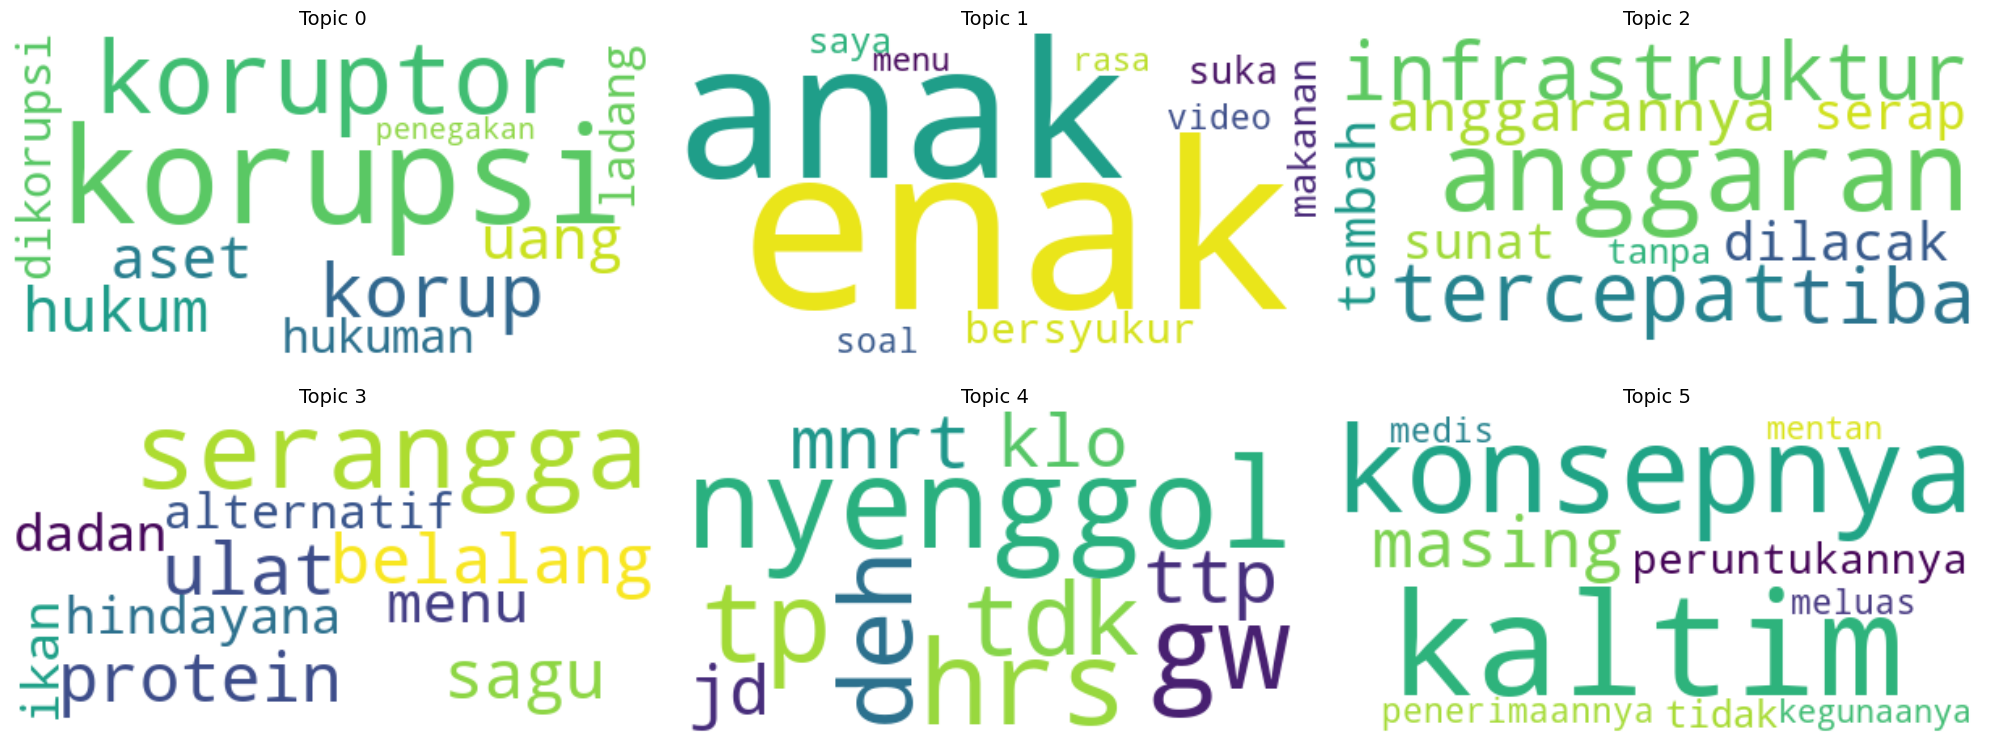

In [124]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(20, 8))  # 2 rows, 5 cols

for i, ax in enumerate(axes.flatten()):
    words = dict(topic_models['distiluse-base-multilingual-cased-v21'].get_topic(i))
    wc = WordCloud(background_color="white").generate_from_frequencies(words)
    
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Topic {i}", fontsize=14)

plt.tight_layout()
plt.show()


# **Top2Vec Hyperparameter Tuning**

In [89]:
def get_top_words(model, topic_num=None, num_words=10):
    """
    Universal getter for top words from BERTopic or Top2Vec.
    """
    if hasattr(model, "get_topic"):  # BERTopic
        words = model.get_topic(topic_num)
        return [w for w, _ in words[:num_words]]

    elif hasattr(model, "get_topic_words"):  # Top2Vec newer API
        words, _ = model.get_topic_words(topic_num=topic_num, num_words=num_words)
        return words

    elif hasattr(model, "get_topics"):  # Top2Vec fallback
        topic_words, _, topic_nums = model.get_topics()
        # If topic_num is given, align with its index
        if topic_num is None:
            raise ValueError("Top2Vec requires a topic_num when using get_topics() fallback")
        idx = list(topic_nums).index(topic_num)
        return topic_words[idx][:num_words]

    else:
        raise ValueError(f"Unsupported model type: {type(model)}")



def evaluate_top2vec_topk(model, topk=20):
    """
    Compute coherence & diversity for the top-k topics of Top2Vec.
    """
    topic_words, _, topic_nums = model.get_topics()
    
    # Limit to top-k topics
    topic_nums = topic_nums[:topk]

    # Build tokenized docs for coherence
    tokenized_docs = [doc.split() for doc in model.documents]
    dictionary = Dictionary(tokenized_docs)

    topic_word_list = [get_top_words(model, t, num_words=10) for t in topic_nums]

    # Compute coherence
    cm = CoherenceModel(
        topics=topic_word_list,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v"
    )
    coherence = cm.get_coherence()

    # Compute diversity
    all_words = [w for topic in topic_word_list for w in topic]
    unique_words = set(all_words)
    diversity = len(unique_words) / len(all_words)

    return coherence, diversity


In [95]:
from top2vec import Top2Vec
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

# Reuse your existing compute_topic_diversity
def compute_topic_diversity_from_top2vec(model, topk=10):
    topic_words, _, _ = model.get_topics()
    topic_words = [words[:topk] for words in topic_words]
    all_words = [word for topic in topic_words for word in topic]
    unique_words = set(all_words)
    return len(unique_words) / len(all_words)


def tune_top2vec(docs,
                 embedding_models=["universal-sentence-encoder", "distiluse-base-multilingual-cased", "universal-sentence-encoder-multilingual"],
                 cluster_size_values=[5, 10, 20],
                 neighbor_values=[10, 15, 30],
                 topk_diversity=10):

    best_model, best_score = None, -1
    results = []

    # Tokenize once
    tokenized_docs = [d.split() for d in docs]
    dictionary = Dictionary(tokenized_docs)

    for emb in embedding_models:
        for min_cluster_size in cluster_size_values:
            for n_neighbors in neighbor_values:
                print(f"Testing: {emb}, min_cluster_size={min_cluster_size}, n_neighbors={n_neighbors}")
                try:
                    model = Top2Vec(
                        documents=docs,
                        embedding_model=emb,
                        speed="learn",
                        umap_args={
                            'n_neighbors': n_neighbors,
                            'n_components': 5,   
                            'min_dist': 0.0,
                            'metric': 'cosine'
                        },
                        hdbscan_args={
                            'min_cluster_size': min_cluster_size,
                            'metric': 'euclidean'
                        }
                    )

                    # Extract topics
                    topic_words, _, _ = model.get_topics()

                    coherence, diversity = evaluate_top2vec_topk(model, 20)

                    # Weighted score (same as BERTopic)
                    score = coherence * 0.5 + diversity * 0.5

                    results.append({
                        "embedding": emb,
                        "n_neighbors": n_neighbors,
                        "n_components": 5,
                        "min_cluster_size": min_cluster_size,
                        "coherence": coherence,
                        "diversity": diversity,
                        "score": score
                    })

                    if score > best_score:
                        best_model, best_score = model, score

                except Exception as e:
                    print(f"⚠️ Error with {emb}, params: {e}")

    results_df = pd.DataFrame(results)
    return best_model, results_df


In [ ]:
df = df_with_stopwords

docs = df['clean_text'].astype(str).tolist()
best_model, results_df = tune_top2vec(docs)

In [97]:
results_df.sort_values(by="score", ascending=False)

,embedding,n_neighbors,n_components,min_cluster_size,coherence,diversity,score
7,universal-sentence-encoder,15,5,20,0.388324,0.666667,0.527495
8,universal-sentence-encoder,30,5,20,0.397209,0.550000,0.473604
6,universal-sentence-encoder,10,5,20,0.394135,0.425000,0.409568
20,universal-sentence-encoder-multilingual,30,5,5,0.380630,0.320000,0.350315
25,universal-sentence-encoder-multilingual,15,5,20,0.365730,0.305000,0.335365
18,universal-sentence-encoder-multilingual,10,5,5,0.364469,0.305000,0.334735
13,distiluse-base-multilingual-cased,15,5,10,0.330579,0.335000,0.332789
12,distiluse-base-multilingual-cased,10,5,10,0.341866,0.320000,0.330933
21,universal-sentence-encoder-multilingual,10,5,10,0.371618,0.290000,0.330809
19,universal-sentence-encoder-multilingual,15,5,5,0.361483,0.300000,0.330742


In [ ]:
df = df_without_stopwords

docs = df['clean_text'].astype(str).tolist()
best_model, results_df = tune_top2vec(docs)

In [99]:
results_df.sort_values(by="score", ascending=False)

,embedding,n_neighbors,n_components,min_cluster_size,coherence,diversity,score
25,universal-sentence-encoder-multilingual,15,5,20,0.359133,0.320,0.339566
11,distiluse-base-multilingual-cased,30,5,5,0.333225,0.345,0.339113
21,universal-sentence-encoder-multilingual,10,5,10,0.367312,0.310,0.338656
26,universal-sentence-encoder-multilingual,30,5,20,0.367257,0.300,0.333628
20,universal-sentence-encoder-multilingual,30,5,5,0.367948,0.295,0.331474
23,universal-sentence-encoder-multilingual,30,5,10,0.361130,0.300,0.330565
18,universal-sentence-encoder-multilingual,10,5,5,0.366327,0.290,0.328164
19,universal-sentence-encoder-multilingual,15,5,5,0.363026,0.290,0.326513
17,distiluse-base-multilingual-cased,30,5,20,0.327926,0.325,0.326463
13,distiluse-base-multilingual-cased,15,5,10,0.334907,0.315,0.324953


In [100]:
from top2vec import Top2Vec
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

topic_models_top2vec = {}
coherence_scores_top2vec = []
diversity_scores_top2vec = []
count = 1

# Example: 6 configs you want to try (embedding + clustering params)
top2vec_configs = [
    {"name": "distiluse-base-multilingual-cased", "min_cluster_size": 10, "n_neighbors": 15},
    {"name": "universal-sentence-encoder", "min_cluster_size": 20, "n_neighbors": 15},
    {"name": "universal-sentence-encoder-multilingual", "min_cluster_size": 5, "n_neighbors": 30},
    {"name": "distiluse-base-multilingual-cased", "min_cluster_size": 5, "n_neighbors": 30},
    {"name": "universal-sentence-encoder", "min_cluster_size": 20, "n_neighbors": 30},
    {"name": "universal-sentence-encoder-multilingual", "min_cluster_size": 20, "n_neighbors": 15},
]

# Precompute tokens + dictionary

for config in top2vec_configs:
    print(f"\n=== Training {config['name']} ===")

    if count < 4:
      df = df_with_stopwords
    else:
      df = df_without_stopwords

    docs = df['clean_text'].astype(str).tolist()
    tokenized_docs = [d.split() for d in docs]
    dictionary = Dictionary(tokenized_docs)

    try:
        # Train Top2Vec model
        model = Top2Vec(
            documents=docs,
            embedding_model=config["name"],
            speed="learn",
            umap_args={
                'n_neighbors': config["n_neighbors"],
                'n_components': 5,
                'min_dist': 0.0,
                'metric': 'cosine'
            },
            hdbscan_args={
                'min_cluster_size': config["min_cluster_size"],
                'metric': 'euclidean'
            }
        )

        # Extract topics
        topic_words, _, _ = model.get_topics()

        coherence, diversity = evaluate_top2vec_topk(model, 20)

        # Save
        if count < 4:
          topic_models_top2vec[config["name"] + "1"] = model
        else:
          topic_models_top2vec[config["name"] + "2"] = model

        coherence_scores_top2vec.append(coherence)
        diversity_scores_top2vec.append(diversity)

        print(f"Coherence: {coherence:.4f}, Diversity: {diversity:.4f}")

        # Try calling get_topics
        topics_out = model.get_topics()
        topic_words, word_scores, topic_nums = topics_out

        # Now get sizes
        topic_sizes, topic_nums = model.get_topic_sizes()

        # Sort topics by size
        sorted_topics = sorted(zip(topic_sizes, topic_nums), reverse=True)
        top_topics = [num for _, num in sorted_topics[:5]]

        print("\nTop 5 Topics:")
        for t in top_topics:
            idx = list(topic_nums).index(t)
            rep_words = ", ".join(topic_words[idx][:10])
            rep_docs = model.search_documents_by_topic(topic_num=t, num_docs=2)

            print(f"\nTopic {t}:")
            print(f"  Words: {rep_words}")
            for d in rep_docs:
                print(f"  Doc: {d[:200]}...")


    except Exception as e:
        print(f"⚠️ Error training {config['name']}: {e}")

    count += 1


2025-08-25 22:16:51,934 - top2vec - INFO - Pre-processing documents for training
INFO:top2vec:Pre-processing documents for training



=== Training distiluse-base-multilingual-cased ===


2025-08-25 22:16:52,217 - top2vec - INFO - Downloading distiluse-base-multilingual-cased model
INFO:top2vec:Downloading distiluse-base-multilingual-cased model
2025-08-25 22:17:13,765 - top2vec - INFO - Creating joint document/word embedding
INFO:top2vec:Creating joint document/word embedding
2025-08-25 22:17:43,838 - top2vec - INFO - Creating lower dimension embedding of documents
INFO:top2vec:Creating lower dimension embedding of documents
2025-08-25 22:17:51,505 - top2vec - INFO - Finding dense areas of documents
INFO:top2vec:Finding dense areas of documents
2025-08-25 22:17:51,595 - top2vec - INFO - Finding topics
INFO:top2vec:Finding topics
2025-08-25 22:17:58,701 - top2vec - INFO - Pre-processing documents for training
INFO:top2vec:Pre-processing documents for training


Coherence: 0.3360, Diversity: 0.3100

Top 5 Topics:

Topic 0:
  Words: program, programnya, mbg, umkmdukungmbg, proyek, bpom, tsb, umkm, apbn, msh
  Doc: ['mbg program yang tidak perlu diragukan lagi lanjutkan bosquuuuu'
 'hashim tegaskan program mbg murni ide gerindra']...
  Doc: [0.8871578 0.8771494]...
  Doc: [1425 3002]...

Topic 1:
  Words: program, programnya, food, kesehatan, makanannya, makanan, makan, sehat, mbg, umkm
  Doc: ['program mbg terbantu umkm agar makanan sehat menjangkau seluruh masyarakat umkmdukungmbg'
 'program mbg yang didukung umkm akan meningkatkan kesejahteraan masyarakat dengan menyediakan makanan sehat yang terjangkau umkmdukungmbg']...
  Doc: [0.9384421  0.91900015]...
  Doc: [7430 7357]...

Topic 2:
  Words: program, sekolah, programnya, pendidikan, pelajar, siswa, belajar, kemiskinan, gratis, murid
  Doc: ['kenpa tidak masing² sekolah saja yang kelola mbg ini dan pemerintah tinggal kasih dana ke masing² sekolah supaya pengelolaannya lebih rapih ini kaya 

2025-08-25 22:17:58,939 - top2vec - INFO - Downloading universal-sentence-encoder model
INFO:top2vec:Downloading universal-sentence-encoder model
2025-08-25 22:18:03,350 - top2vec - INFO - Creating joint document/word embedding
INFO:top2vec:Creating joint document/word embedding
2025-08-25 22:18:04,125 - top2vec - INFO - Creating lower dimension embedding of documents
INFO:top2vec:Creating lower dimension embedding of documents
2025-08-25 22:18:11,842 - top2vec - INFO - Finding dense areas of documents
INFO:top2vec:Finding dense areas of documents
2025-08-25 22:18:11,960 - top2vec - INFO - Finding topics
INFO:top2vec:Finding topics
2025-08-25 22:18:19,078 - top2vec - INFO - Pre-processing documents for training
INFO:top2vec:Pre-processing documents for training


...

Coherence: 0.3376, Diversity: 0.3400

Top 5 Topics:

Topic 0:
  Words: program, food, programnya, makanan, makanannya, kesehatan, mbg, makan, umkmdukungmbg, umkm
  Doc: ['program mbg terbantu umkm makanan sehat menjangkau masyarakat umkmdukungmbg'
 'program mbg didukung umkm hadirkan pangan sehat penuh cita umkmdukungmbg']...
  Doc: [0.9520206  0.94580454]...
  Doc: [7430 6845]...

Topic 1:
  Words: program, programnya, mbg, umkmdukungmbg, bpom, umkm, dlm, rb, apbn, dprd
  Doc: ['mengelola program mbg' 'layak program mbg']...
  Doc: [0.98455846 0.97599983]...
  Doc: [ 554 7817]...

Topic 2:
  Words: anggarannya, anggaran, program, programnya, mbg, keuangan, ekonomimaju, biaya, ekonomi, rumah
  Doc: ['gara mbg sich program pelaksanaannya acakadul pos anggaran dikorbankan'
 'smoga kedepannya program mbg dpt ditangani lbih sgt kuragukan jg dg ketersediaan anggarannya brlgsg program']...
  Doc: [0.9232404 0.9203601]...
  Doc: [2288 2088]...

Topic 3:
  Words: gratis, program, programnya, m

2025-08-25 22:19:56,585 - top2vec - INFO - Downloading universal-sentence-encoder model
INFO:top2vec:Downloading universal-sentence-encoder model
2025-08-25 22:20:01,002 - top2vec - INFO - Creating joint document/word embedding
INFO:top2vec:Creating joint document/word embedding
2025-08-25 22:20:01,677 - top2vec - INFO - Creating lower dimension embedding of documents
INFO:top2vec:Creating lower dimension embedding of documents
2025-08-25 22:20:12,548 - top2vec - INFO - Finding dense areas of documents
INFO:top2vec:Finding dense areas of documents
2025-08-25 22:20:12,658 - top2vec - INFO - Finding topics
INFO:top2vec:Finding topics
2025-08-25 22:20:19,435 - top2vec - INFO - Pre-processing documents for training
INFO:top2vec:Pre-processing documents for training


Coherence: 0.3941, Diversity: 0.2300

Top 5 Topics:

Topic 0:
  Words: masuk, pake, gimana, anak, banget, harga, nggak, bikin, kasih, coba
  Doc: ['program makan bergizi gratis mbg resmi januari titik tersebar provinsi indonesia dilaksanakan presiden prabowo subianto dilantik program bertujuan memenuhi kebutuhan gizi anak anak sekolah'
 'dukung program makan bergizi gratis mbg investasi jangka gizi anak indonesia mbg dukungprogrampresiden']...
  Doc: [0.9350497  0.93156534]...
  Doc: [8462 8555]...

Topic 1:
  Words: masuk, gimana, pake, nggak, harga, bikin, budi, sih, banget, nih
  Doc: ['program unggulan presiden makanbergizigratis mbg hadir solusi nyata anak indonesia tumbuh sehat cerdas berdaya mbg indonesiahebat dukungpresiden generasisehat indonesiamaju tumbuhbersama foodforall trendingvideo'
 'program unggulan presiden makanbergizigratis mbg hadir solusi nyata anak indonesia tumbuh sehat cerdas berdaya mbg indonesiahebat dukungpresiden generasisehat indonesiamaju tumbuhbersama f

2025-08-25 22:20:19,617 - top2vec - INFO - Downloading universal-sentence-encoder-multilingual model
INFO:top2vec:Downloading universal-sentence-encoder-multilingual model
2025-08-25 22:20:20,588 - top2vec - INFO - Creating joint document/word embedding
INFO:top2vec:Creating joint document/word embedding
2025-08-25 22:20:24,381 - top2vec - INFO - Creating lower dimension embedding of documents
INFO:top2vec:Creating lower dimension embedding of documents
2025-08-25 22:20:32,418 - top2vec - INFO - Finding dense areas of documents
INFO:top2vec:Finding dense areas of documents
2025-08-25 22:20:32,529 - top2vec - INFO - Finding topics
INFO:top2vec:Finding topics


Coherence: 0.3737, Diversity: 0.2850

Top 5 Topics:

Topic 0:
  Words: mbg, program, programnya, umkmdukungmbg, apbn, apbd, blm, sdm, anggarannya, dg
  Doc: ['loe ngedukung mbg program kajian gitu'
 'semoga program mbg berlanjut banget']...
  Doc: [0.91048825 0.9092919 ]...
  Doc: [3201 1793]...

Topic 1:
  Words: umkmdukungmbg, pangan, mbg, sehat, bergizi, program, programnya, gizi, apbd, umkm
  Doc: ['program mbg didukung umkm pangan sehat mudah diakses umkmdukungmbg'
 'program mbg terbantu umkm makanan sehat menjangkau masyarakat umkmdukungmbg']...
  Doc: [0.9423462 0.9369952]...
  Doc: [7180 7430]...

Topic 2:
  Words: prabowo, kampanye, presiden, wapres, rakyat, programnya, program, semoga, mbg, korupsi
  Doc: ['program makan bergizi gratis mbg langkah nyata pemerintahan presiden prabowo mbg programmbg prabowo'
 'program makan bergizi gratis mbg langkah nyata pemerintahan presiden prabowo mbg programmbg prabowo']...
  Doc: [0.9216835 0.9216835]...
  Doc: [5488 5487]...

Topic 3:
 

In [101]:
print("With stopwords df, distiluse-base-multilingual-cased embedding model")
print("Coherence score: ", coherence_scores_top2vec[0], "; Topic diversity: ", diversity_scores_top2vec[0])
print("")
print("With stopwords df, universal-sentence-encoder embedding model")
print("Coherence score: ", coherence_scores_top2vec[1], "; Topic diversity: ", diversity_scores_top2vec[1])
print("")
print("With stopwords df, universal-sentence-encoder-multilingual embedding model")
print("Coherence score: ", coherence_scores_top2vec[2], "; Topic diversity: ", diversity_scores_top2vec[2])
print("")
print("Without stopwords df, distiluse-base-multilingual-cased embedding model")
print("Coherence score: ", coherence_scores_top2vec[3], "; Topic diversity: ", diversity_scores_top2vec[3])
print("")
print("Without stopwords df, universal-sentence-encoder embedding model")
print("Coherence score: ", coherence_scores_top2vec[4], "; Topic diversity: ", diversity_scores_top2vec[4])
print("")
print("Without stopwords df, universal-sentence-encoder-multilingual embedding model")
print("Coherence score: ", coherence_scores_top2vec[5], "; Topic diversity: ", diversity_scores_top2vec[5])
print("")


With stopwords df, distiluse-base-multilingual-cased embedding model
Coherence score:  0.33599786051790376 ; Topic diversity:  0.31

With stopwords df, universal-sentence-encoder embedding model
Coherence score:  0.3796731729357452 ; Topic diversity:  0.6333333333333333

With stopwords df, universal-sentence-encoder-multilingual embedding model
Coherence score:  0.37453884588898606 ; Topic diversity:  0.32

Without stopwords df, distiluse-base-multilingual-cased embedding model
Coherence score:  0.3376029269156505 ; Topic diversity:  0.34

Without stopwords df, universal-sentence-encoder embedding model
Coherence score:  0.3941204228001246 ; Topic diversity:  0.23

Without stopwords df, universal-sentence-encoder-multilingual embedding model
Coherence score:  0.3737370044319398 ; Topic diversity:  0.285



In [102]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from umap import UMAP
import math
import numpy as np

pio.renderers.default = "browser"

from sklearn.decomposition import PCA

def visualize_top2vec_models(topic_models, top_n=20):
    """
    topic_models: dict { "ModelName": Top2Vec_model, ... }
    top_n: number of top topics to visualize
    """
    fig = make_subplots(rows=2, cols=3, subplot_titles=[name[:-1] for name in topic_models.keys()])

    for i, (name, model) in enumerate(topic_models.items(), start=0):
        row = math.ceil((i+1) / 3)
        col = (i % 3) + 1  

        # Get topic sizes
        topic_sizes, topic_nums = model.get_topic_sizes()

        # Sort topics by size descending
        sorted_indices = np.argsort(topic_sizes)[::-1]
        top_indices = sorted_indices[:top_n]

        topic_vecs = model.topic_vectors[top_indices]
        n_samples = topic_vecs.shape[0]

        # Choose dimensionality reduction method
        if n_samples > 5:
            n_neighbors = min(10, n_samples - 1)
            reducer = UMAP(
                n_neighbors=n_neighbors,
                n_components=2,
                metric="cosine",
                random_state=42
            )
            topic_vectors_2d = reducer.fit_transform(topic_vecs)
        else:
            # fallback to PCA if too few samples
            reducer = PCA(n_components=2, random_state=42)
            topic_vectors_2d = reducer.fit_transform(topic_vecs)

        # Scale marker sizes
        marker_sizes = np.array(topic_sizes)[top_indices]
        marker_sizes = 10 + (marker_sizes / marker_sizes.max()) * 40

        # Add scatter
        fig.add_trace(
            go.Scatter(
                x=topic_vectors_2d[:, 0],
                y=topic_vectors_2d[:, 1],
                mode="markers+text",
                # text=[f"Topic {t}" for t in np.array(topic_nums)[top_indices]],
                textposition="top center",
                marker=dict(
                    size=marker_sizes,
                    color=marker_sizes,  # color by size
                    colorscale="Blues",
                    line=dict(width=1, color="black")
                ),
                name=name
            ),
            row=row, col=col
        )

        fig.update_xaxes(title_text="x", row=row, col=col)
        fig.update_yaxes(title_text="y", row=row, col=col)

    fig.update_layout(
        title_text=f"Top2Vec Topic Model Comparison (Top {top_n} Topics)",
        showlegend=False,
        height=900,
        width=1200
    )

    fig.show()



visualize_top2vec_models(topic_models_top2vec)

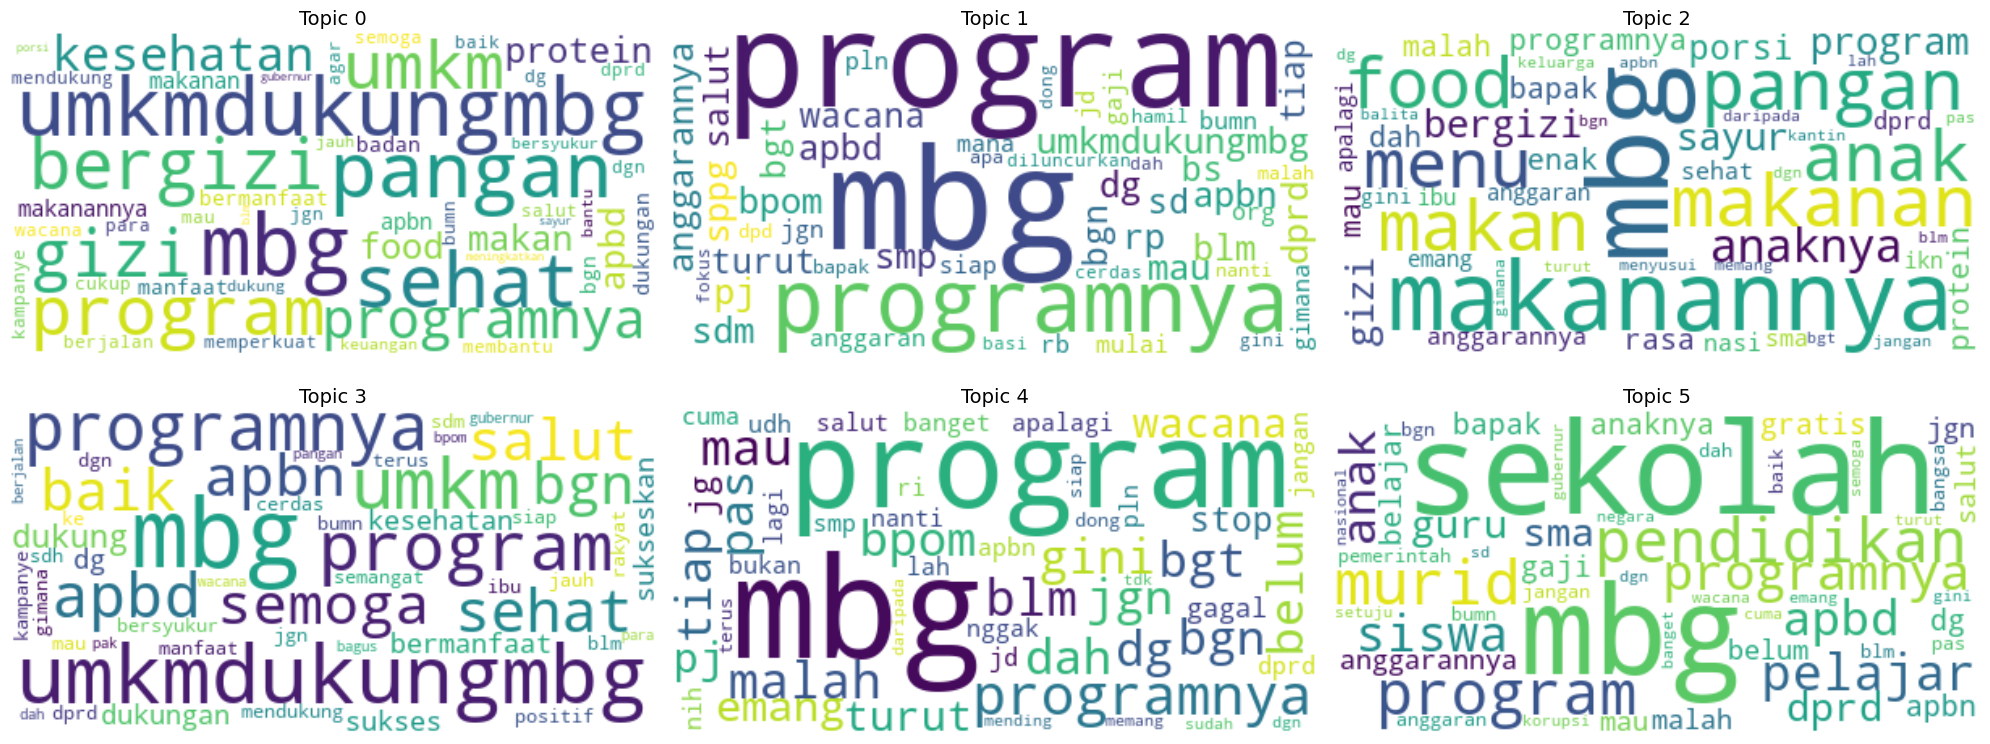

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Assume you already have a trained Top2Vec model called `top2vec_model`
# Get all topics
topic_words, word_scores, topic_nums = topic_models_top2vec['universal-sentence-encoder-multilingual1'].get_topics()

fig, axes = plt.subplots(2, 3, figsize=(20, 8))  # 2 rows, 5 cols

for i, ax in enumerate(axes.flatten()):
    # Build dictionary of {word: score} for topic i
    words = dict(zip(topic_words[i], word_scores[i]))
    wc = WordCloud(background_color="white").generate_from_frequencies(words)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Topic {topic_nums[i]}", fontsize=14)

plt.tight_layout()
plt.show()


Topik terbesar: 8244 tweets


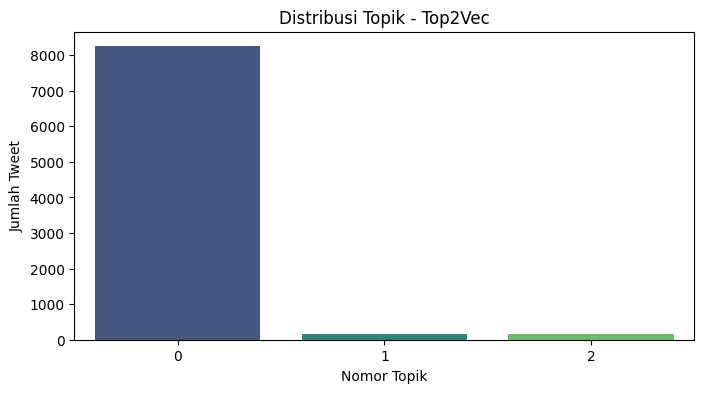

In [103]:
# NOT FINAL CHECK AGAIN

topic_sizes, topic_nums = topic_models_top2vec["universal-sentence-encoder1"].get_topic_sizes()
print(f"Topik terbesar: {topic_sizes[0]} tweets")

# Visualisasi distribusi topik Top2Vec
plt.figure(figsize=(8,4))
sns.barplot(x=topic_nums, y=topic_sizes, palette='viridis')
plt.title("Distribusi Topik - Top2Vec")
plt.xlabel("Nomor Topik")
plt.ylabel("Jumlah Tweet")
plt.show()

# **Comparison**

In [104]:
for i, (name, model) in enumerate(topic_models.items()):
    for k in [10, 20, 30, 50]:
        coherence, diversity = evaluate_topk_topics(model, model.topics_, k=k)
        print(f"k={k} | coherence={coherence:.4f}, diversity={diversity:.4f}")
    print("")

k=10 | coherence=0.6596, diversity=0.8900
k=20 | coherence=0.6264, diversity=0.9000
k=30 | coherence=0.5836, diversity=0.9033
k=50 | coherence=0.5948, diversity=0.8400

k=10 | coherence=0.5704, diversity=0.9900
k=20 | coherence=0.6154, diversity=0.9700
k=30 | coherence=0.6337, diversity=0.9400
k=50 | coherence=0.6436, diversity=0.9200

k=10 | coherence=0.6408, diversity=0.9700
k=20 | coherence=0.6307, diversity=0.9250
k=30 | coherence=0.6121, diversity=0.9267
k=50 | coherence=0.6289, diversity=0.9120

k=10 | coherence=0.6505, diversity=0.9400
k=20 | coherence=0.5904, diversity=0.9300
k=30 | coherence=0.5933, diversity=0.8967
k=50 | coherence=0.6246, diversity=0.8320

k=10 | coherence=0.5593, diversity=0.9900
k=20 | coherence=0.5737, diversity=0.9600
k=30 | coherence=0.5869, diversity=0.9533
k=50 | coherence=0.5881, diversity=0.9360

k=10 | coherence=0.6040, diversity=0.9800
k=20 | coherence=0.5922, diversity=0.9600
k=30 | coherence=0.5959, diversity=0.9100
k=50 | coherence=0.5915, dive

In [105]:
for i, (name, model) in enumerate(topic_models_top2vec.items()):
    for k in [10, 20, 30, 50]:
        coherence, diversity = evaluate_top2vec_topk(model, topk=k)
        print(f"k={k} | coherence={coherence:.4f}, diversity={diversity:.4f}")
    print("")


k=10 | coherence=0.3357, diversity=0.4400
k=20 | coherence=0.3360, diversity=0.3100
k=30 | coherence=0.3383, diversity=0.2733
k=50 | coherence=0.3363, diversity=0.2040

k=10 | coherence=0.3797, diversity=0.6333
k=20 | coherence=0.3797, diversity=0.6333
k=30 | coherence=0.3797, diversity=0.6333
k=50 | coherence=0.3797, diversity=0.6333

k=10 | coherence=0.3809, diversity=0.5100
k=20 | coherence=0.3745, diversity=0.3200
k=30 | coherence=0.3585, diversity=0.2533
k=50 | coherence=0.3611, diversity=0.1980

k=10 | coherence=0.3385, diversity=0.4500
k=20 | coherence=0.3376, diversity=0.3400
k=30 | coherence=0.3325, diversity=0.2533
k=50 | coherence=0.3296, diversity=0.1920

k=10 | coherence=0.3806, diversity=0.3000
k=20 | coherence=0.3941, diversity=0.2300
k=30 | coherence=0.3912, diversity=0.2167
k=50 | coherence=0.3940, diversity=0.2129

k=10 | coherence=0.3826, diversity=0.4400
k=20 | coherence=0.3737, diversity=0.2850
k=30 | coherence=0.3652, diversity=0.2367
k=50 | coherence=0.3508, dive

In [138]:
topic_model = topic_models['distiluse-base-multilingual-cased-v21']

top_topics = topic_model.get_topic_freq().head(21)["Topic"].tolist()  # exclude -1 if present
if -1 in top_topics:
    top_topics.remove(-1)

for t in top_topics[:30]:
    words = topic_model.get_topic(t)
    rep_words = ", ".join([w for w, _ in words[:10]])
    rep_docs = topic_model.get_representative_docs(t)[:3] 
    print(f"\nTopic {t}:")
    print(f"  Words: {rep_words}")
    for d in rep_docs:
        print(f"  Doc: {d[:200]}...")


Topic 0:
  Words: korupsi, koruptor, korup, hukum, aset, uang, hukuman, dikorupsi, ladang, penegakan
  Doc: hentikan saja program mbg min tidak bermanfaat amp menjadi peluang korupsi baru sebaiknya fokus kpd penegakan hukum pengelolaan sda mineral tambang yang berdaya guna efisien perampasan aset koruptor p...
  Doc: sebenarnya yang harus dilakukan adalah memberantas korupsi dulu sikat sampai ke akarnya kalau tidak sebanyak apapun program nya apalagi yang melibatkan uang yang banyak seperti mbg dll pasti akan di k...
  Doc: lah kok jadi minta duit rakyat sih rakyat kurang apa lagi coba udh mah harus bayar pajak terus naik lagi belum lagi dikorup pejabat sekarang suruh ikut nalangin program mbg ambil saja dari tunjangan y...

Topic 1:
  Words: enak, anak, bersyukur, makanan, suka, saya, video, soal, menu, rasa
  Doc: orang dewasa tuh lihat ada yang tidak mau makan picky eater udah stop saja program ini anak kecil yang dapat mbg ke temannya aku tidak suka lauk ini buat kamu saja yah ana

In [144]:
model = topic_models_top2vec['universal-sentence-encoder-multilingual1']

# Try calling get_topics
topics_out = model.get_topics()
topic_words, word_scores, topic_nums = topics_out

# Now get sizes
topic_sizes, topic_nums = model.get_topic_sizes()

# Sort topics by size
sorted_topics = sorted(zip(topic_sizes, topic_nums), reverse=True)
top_topics = [num for _, num in sorted_topics[20:22]]

print("\nTop 5 Topics:")
for t in top_topics:
    idx = list(topic_nums).index(t)
    rep_words = ", ".join(topic_words[idx][:10])
    rep_docs = model.search_documents_by_topic(topic_num=t, num_docs=40)

    print(f"\nTopic {t}:")
    print(f"  Words: {rep_words}")
    for d in rep_docs:
        print(f"  Doc: {d[:200]}...")


Top 5 Topics:

Topic 20:
  Words: mbg, programnya, program, belum, pas, bukan, tidak, bpom, apbn, sppg
  Doc: ['mbg itu program tidak masuk akal'
 'lagi mikir kenapa tidak dari dulu yah program mbg'
 'beliau ini pasti tidak kebagian program mbg'
 'bilang saja program mbg itu kurang ato tidak ada dananyaaa ah elah'
 'lha program mbg ps apa tidak dipaksakan juga'
 'isu tidak jelas ini program mbg itu terjamin dan terpantau'
 'program mbg ini ternyata tidak pernah dipikirkan darimana sumber dana nya'
 'tidak begitu mendukung program mbg'
 'jan ethes pernah ikut program mbg tidak yah'
 'program mbg itu bukan punya kekurangan tapi program mbg itu sendiri adalah sebuah kekurangan'
 'dindik lebak belum laksanakan program mbg'
 'program tidak masuk akal contohnya mbg'
 'mbg program bagus cm duit nya yang tak siap'
 'jangaann paakk kl mmg tidak berhasil akui saja dan segera batalkan program mbg ini'
 'mbg program yang tidak perlu diragukan lagi lanjutkan bosquuuuu'
 'terus loe juga ngedukung m